# Triển khai trên Whisper của OpenAI

# Nhuoc diem: cac mo hinh opensource STT tieng viet thuong khong gioi trong cac tu vung chuyen nganh

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import locale
locale.getpreferredencoding = lambda : "UTF-8"

In [ ]:
# !pip install -q openai-whisper ffmpeg pydub

In [ ]:
# !pip install sounddevice scipy

In [4]:
import sounddevice as sd
from scipy.io.wavfile import write
import whisper

In [ ]:
# Record audio and save the file WAV
def record_audio_local(filename="audio.wav", duration=10, samplerate=44100):
    print("Start recording...")
    recording = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='int16')
    sd.wait()
    write(filename, samplerate, recording)
    print(f"Recording saved to {filename}")

record_audio_local(duration=5) 

Start recording...
Recording saved to audio.wav


In [5]:
# Recognize voice using Whisper
def transcribe_audio(filename="test-sound.wav", lang="vietnamese"):
    print("Transcribing audio...")
    model = whisper.load_model("base") # "tiny" "base" "small", "medium", "large", "turbo"
    result = model.transcribe(filename, language=lang)
    return result["text"]

text = transcribe_audio()
print("Speech to text:", text)

Transcribing audio...
Speech to text:  và là chính anh IT mà là truyên ngành chữ tuệ nhân tạng. Để bến cạnh đó thì nếu bố của mình mỗi ngày khi đến trường đó là được làm việc với các bạn chè. Các bạn có đăng mưu, vì tim, hảo đăng mưu con nghe, tim tòi, và luôn lực để thấy được cái khả năng, cái đóng gốc của mình vào trong ngành IT.


# PhoWhisper của VinAI

In [ ]:
# !pip install transformers

In [7]:
from transformers import pipeline
pipe = pipeline("automatic-speech-recognition", model="vinai/PhoWhisper-base")

# # Load model directly
# from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
# processor = AutoProcessor.from_pretrained("vinai/PhoWhisper-base")
# model = AutoModelForSpeechSeq2Seq.from_pretrained("vinai/PhoWhisper-base")

d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cuda:0


In [1]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

import sounddevice as sd
from scipy.io.wavfile import write
from transformers import pipeline

# # Record audio at 16kHz mono
# def record_audio_local(filename="audio.wav", duration=5, samplerate=16000):
#     print("Start recording...")
#     recording = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='int16')
#     sd.wait()
#     write(filename, samplerate, recording)
#     print(f"Recording saved to {filename}")

# record_audio_local(duration=5, samplerate=16000)

d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# PhoWhisper transcription
def transcribe_audio_pho(filename="audio.wav"):
    pipe = pipeline("automatic-speech-recognition", model="vinai/PhoWhisper-large")
    result = pipe(filename)
    return result['text']

# Record and transcribe
text = transcribe_audio_pho("test-sound.wav")
print("Speech to text (PhoWhisper):", text)

d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\5530\.cache\huggingface\hub\models--vinai--PhoWhisper-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cuda:0
d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\transformers\models\whis

Speech to text (PhoWhisper): không phải là chuyên ngành ai ti mà là chuyên ngành trí tuệ nhân tạo dạ và bên cạnh đó thì niềm vui của mình mỗi ngày khi đến trường đó là được làm việc với các bạn trẻ các bạn có đam mê về tìm đam mê công nghệ tìm tòi và luôn nỗ lực để để để thấy được cái khả năng ờ cái đóng góp của mình vào trong ngành ai ti.


In [10]:
# PhoWhisper transcription
def transcribe_audio_pho(filename="audio.wav"):
    pipe = pipeline("automatic-speech-recognition", model="vinai/PhoWhisper-tiny")
    result = pipe(filename)
    return result['text']

# Record and transcribe
text = transcribe_audio_pho("test-sound.wav")
print("Speech to text (PhoWhisper):", text)

Device set to use cuda:0


Speech to text (PhoWhisper): không phải là chỉ ngành ai ti mà là ờ chuyên ngành à trí tuệ nhân tạo dạ ờm và bên cạnh đó thì niềm vui của mình mỗi ngày khi đến trường đó là được cả làm việc với các bạn trẻ các bạn có đam mê ờ về tìm đam mê công nghệ thì mờ tòi và luôn nỗ lực để ờ để để thấy được cái khả năng ờ cái đóng góp của mình vào trong ngành ai ti.


In [11]:
# PhoWhisper transcription
def transcribe_audio_pho(filename="audio.wav"):
    pipe = pipeline("automatic-speech-recognition", model="vinai/PhoWhisper-small")
    result = pipe(filename)
    return result['text']

# Record and transcribe
text = transcribe_audio_pho("test-sound.wav")
print("Speech to text (PhoWhisper):", text)

Device set to use cuda:0


Speech to text (PhoWhisper): không phải là chỉ ngành ai ti mà là à chuyên ngành à trí tuệ nhân tạo à bên cạnh đó thì niềm vui của mình mỗi ngày khi đến trường đó là được à làm việc với các bạn trẻ các bạn có đam mê về tìm đam mê công nghệ tìm ờ tòi và luôn nỗ lực để ở để thấy được cái khả năng ờ cái đóng góp của mình vào trong ngành ai ti.


# wav2vec https://huggingface.co/nguyenvulebinh/wav2vec2-base-vietnamese-250h

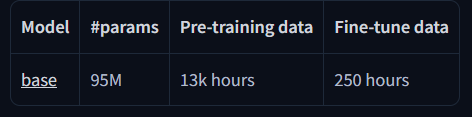

In [13]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import soundfile as sf
import torch

# Tải mô hình và bộ xử lý
processor = Wav2Vec2Processor.from_pretrained("nguyenvulebinh/wav2vec2-base-vietnamese-250h")
model = Wav2Vec2ForCTC.from_pretrained("nguyenvulebinh/wav2vec2-base-vietnamese-250h")

# Đọc tệp âm thanh
speech, _ = sf.read("test-sound.wav")
if len(speech.shape) == 2:  # If stereo, convert to mono
    speech = speech.mean(axis=1)
print("Shape:", speech.shape, "Sample rate:", _)
print("Duration (seconds):", len(speech) / _)
# Tiền xử lý và dự đoán
input_values = processor(speech, return_tensors="pt").input_values
logits = model(input_values).logits
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)
print(transcription)


It is strongly recommended to pass the `sampling_rate` argument to `Wav2Vec2FeatureExtractor()`. Failing to do so can result in silent errors that might be hard to debug.


Shape: (1219584,) Sample rate: 48000
Duration (seconds): 25.408
['à à     t a tan tả tất đà n  tt   vợ tcũng t n t ty từ nt n t t tà  đ']


# ChunkFormer - https://huggingface.co/khanhld/chunkformer-large-vie

python decode.py --model_checkpoint "D:/Ky 4/vietnamese-speech-chatbox/notebooks/chunkformer/chunkformer-large-vie" --long_form_audio "D:/Ky 4/vietnamese-speech-chatbox/notebooks/test-sound.wav" --total_batch_duration 14400 --chunk_size 64 --left_context_size 128 --right_context_size 128

python decode.py \
  --model_checkpoint "D:/Ky 4/vietnamese-speech-chatbox/notebooks/chunkformer/chunkformer-large-vie" \
  --long_form_audio "D:/Ky 4/vietnamese-speech-chatbox/notebooks/test-sound.wav" \
  --total_batch_duration 14400 \
  --chunk_size 64 \
  --left_context_size 128 \
  --right_context_size 128


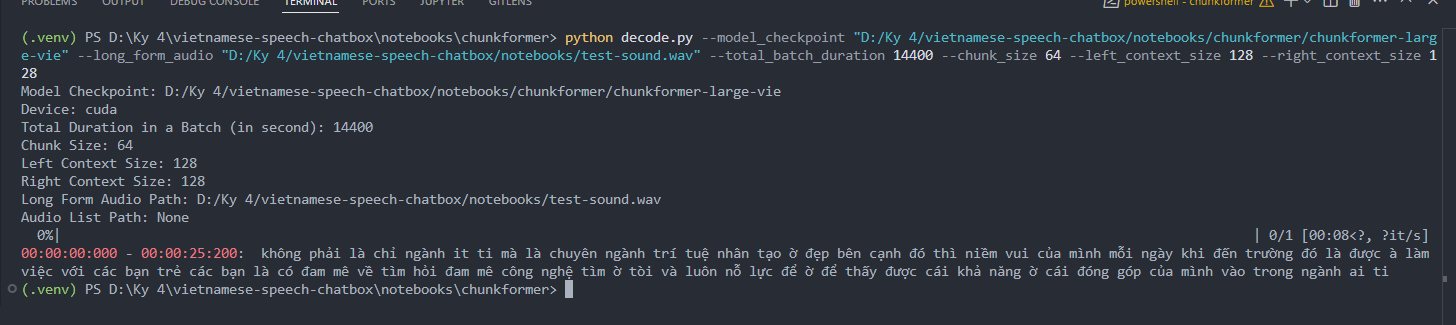

# API

In [3]:
from google import genai
import os
from dotenv import load_dotenv

secret_key = os.getenv("SECRET_KEY")
client = genai.Client(api_key=secret_key)

myfile = client.files.upload(file="test-sound.wav")

response = client.models.generate_content(
    model="gemini-2.0-flash", contents=["Trích xuất vietnamese text từ audio tôi cung cấp", myfile]
)

print(response.text)

không phải là chuyên ngành IT mà là chuyên ngành trí tuệ nhân tạo. Dạ. À. về bên cạnh đó thì niềm vui của mình mỗi ngày khi đến trường đó là được làm việc với các bạn trẻ. Các bạn có đam mê về tìm đam mê công nghệ, tìm tòi và luôn nỗ lực để à để để thấy được cái khả năng ờ cái đóng góp của mình vào trong ngành IT.


In [8]:
response = client.models.count_tokens(
  model='gemini-2.0-flash',
  contents=[myfile]
)

print(response)

total_tokens=815 cached_content_token_count=None


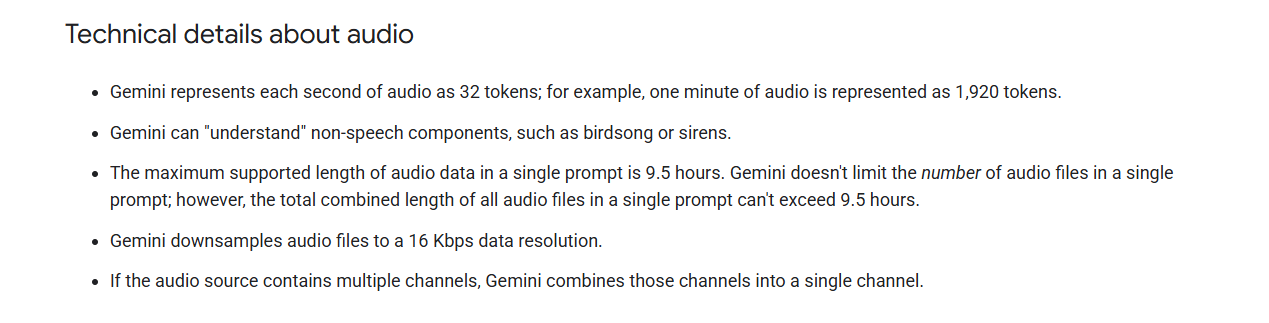

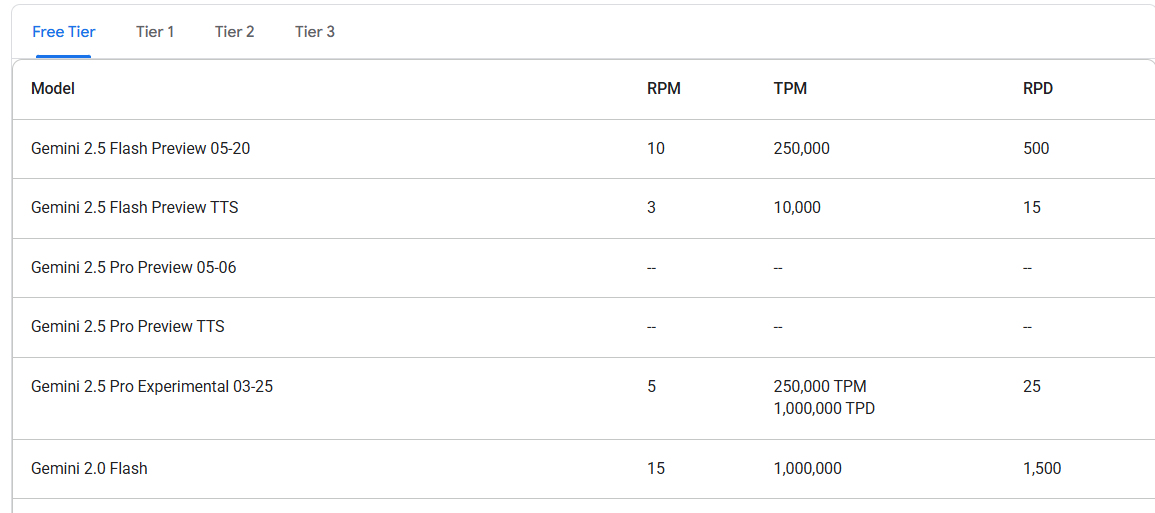